In [1]:
from _Aplha_n_methods import Alpha_N_calc as an
from _Aplha_n_methods import init_worker
from _Geometry_methods import Geometry_helper as gh
from _Prettyplt import PrettyPlot as pp

import openmc
import numpy as np
import matplotlib.pyplot as plt
import os


import openmc.deplete as dep
import time
from collections import defaultdict #To use dictionaries to remove dublicates

In [2]:
#Setting geometry and materials
#Geometry
new_geom = True
fuel_name="Fuel_C"


if new_geom:
    inner_fuel_r = 115
    outer_fuel_r = 120
    outer_moderater_r = 180

    with_blanket = True
    inner_moderator_height = 160
    blanket_or = 200
    geom, mat= gh.set_geom_fuel_shell(inner_fuel_r,outer_fuel_r,outer_moderater_r,with_blanket=with_blanket,
                               blanket_or=blanket_or, inner_moderator_height=inner_moderator_height, fuel_name=fuel_name)
else:
    openmc.reset_auto_ids()
    geom = openmc.Geometry.from_xml("geometry.xml")
    mat = openmc.Materials.from_xml('materials.xml')
fuel = gh.get_material_by_name(fuel_name,mat)


Fuel_CA_1
Fuel_CA_2
Blanket_CA
Fuel_A
Fuel_B
Fuel_C
Air
h2o
d2o
uo2


In [3]:
#Settings
inner_fuel_radius = geom.get_surfaces_by_name('fuel_inner')[0].bounding_box('-')[1][0]
outer_fuel_radius = geom.get_surfaces_by_name('fuel_outer')[0].bounding_box('-')[1][0]
    
settings = openmc.Settings()
settings.run_mode = 'eigenvalue'
settings.batches = 100
settings.inactive = 10
settings.particles = 10000

(<scipy.interpolate._bsplines.BSpline at 0x70d2a3936250>,
 array([2363812.        , 2364375.67516752, 2364939.35033503, ...,
        7998872.64966497, 7999436.32483248, 8000000.        ],
       shape=(10000,)))

/openmc_venv/lib/python3.11/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=1.
  warn(msg, IDWarning)


setup done in 0.8136532610005816 s
0


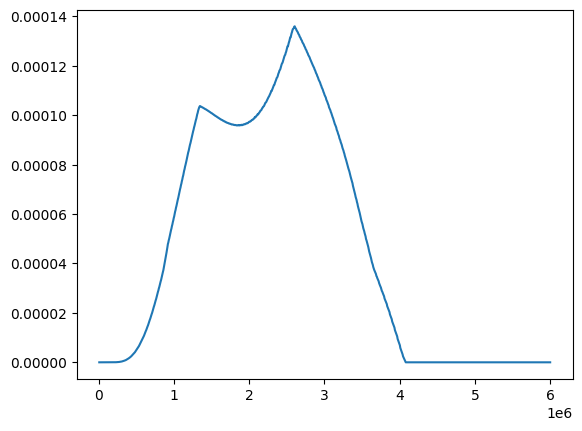

setup done in 0.8976274409978942 s
0


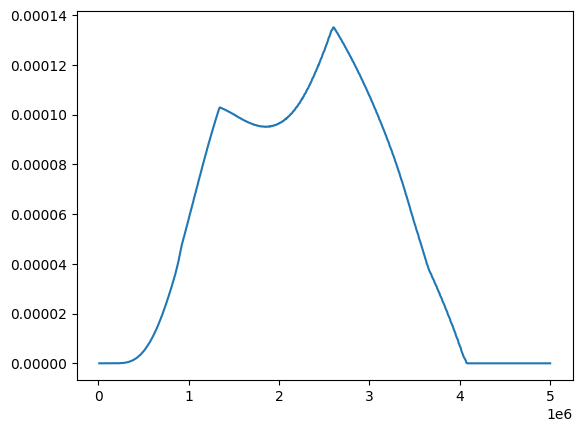

In [8]:
neutron_intensities,neutron_energies,total_n_per_s = an.neutron_spectra_from_material(fuel,E_min=1e4,nr_points=1000,nr_energies=1000,new_file=False)
neutron_intensities = np.clip(neutron_intensities,0,None)
energy = openmc.stats.Tabular(neutron_energies, neutron_intensities)

fig,ax =plt.subplots()

ax.plot(neutron_energies,neutron_intensities)

print(total_n_per_s)

In [11]:
#Setting soruce
inner_fuel = geom.get_surfaces_by_name('fuel_inner')[0]
outer_fuel = geom.get_surfaces_by_name('fuel_outer')[0]

fuel_space = +inner_fuel & -outer_fuel
src = openmc.IndependentSource(
    space=fuel_space, energy=energy,
    particle='neutron', strength=total_n_per_s)
settings.run_mode = 'fixed source'
settings.source = [src]   # evt. + SF-kilde som separat source


#model.run()

TypeError: Unable to set "spatial distribution" to "(2 -1)" which is not of type "Spatial"